```
Copyright (c) 2024-2025 National Institute of Advanced Industrial Science and Technology (AIST)
All rights reserved.
This software is released under the MIT License.
http://opensource.org/licenses/mit-license.php
```

## Introduction
In this notebook you will learn the advanced use of the ef_crafter and the ef_capture.

1. [Simultaneously send frames from port0 to port1 and from port2 to port1 and record the send and receive times](#1.-Simultaneously-send-frames-from-port0-to-port1-and-from-port2-to-port1-and-record-the-send-and-receive-times)
   1. [Make initial settings](#1-A.-Make-initial-settings)
   2. [Set up the AXIS Switch](#1-B.-Set-up-the-AXIS-Switch)
   3. [Update ef_capture setting](#1-C.-Update-ef_capture-setting)
   4. [Prepare send frames](#1-D.-Prepare-send-frames)
   5. [Send frames from port0 and port2 simultaneously, in repeat mode](#1-E.-Send-frames-from-port0-and-port2-simultaneously,-in-repeat-mode)
   6. [Transfer the recorded timestamps to the host computer](#1-F.-Transfer-the-recorded-timestamps-to-the-host-computer)
   7. [Check the recorded timestamps](#1-G.-Check-the-recorded-timestamps)
   8. [Evaluate latency and throughput for each input port](#1-H.-Evaluate-latency-and-throughput-for-each-input-port)
2. [Send frames by adjusting the frame interval to match the target transfer rate](#2.-Send-frames-by-adjusting-the-frame-interval-to-match-the-target-transfer-rate)
   1. [Update internal switch configuration](#2-A.-Update-internal-switch-configuration)
   2. [Update ef_capture setting](#2-B.-Update-ef_capture-setting)
   3. [Prepare send frames (Constant rate)](#2-C.-Prepare-send-frames-(Constant-rate))
   4. [Send frames from port0 to port1, in repeat mode](#2-D.-Send-frames-from-port0-to-port1,-in-repeat-mode)
   5. [Transfer the recorded timestamps to the host computer](#2-E.-Transfer-the-recorded-timestamps-to-the-host-computer)
   6. [Evaluate latency and throughput for each input port](#2-F.-Evaluate-latency-and-throughput-for-each-input-port)
3. [Sends frames at a random transmission rate that follows an exponential distribution](#3.-Sends-frames-at-a-random-transmission-rate-that-follows-an-exponential-distribution)
   1. [Generate random numbers that follow an exponential distribution](#3-A.-Generate-random-numbers-that-follow-an-exponential-distribution)
   2. [Prepare send frames (Exponential distribution)](#3-B.-Prepare-send-frames-(Exponential-distribution))
   3. [Send frames from port0 to port1, in repeat mode](#3-C.-Send-frames-from-port0-to-port1,-in-repeat-mode)
   4. [Transfer the recorded timestamps to the host computer](#3-D.-Transfer-the-recorded-timestamps-to-the-host-computer)
   5. [Evaluate latency and throughput](#3-E.-Evaluate-latency-and-throughput)

In [1]:
import argparse
import tsn_efcc
import pyxsdb
import sys
import ipywidgets as widgets
from IPython.display import Markdown, display, Image

FREQ_MHZ = 156.25

# First, select the network configuration to use using the following radio buttons.
# If the ports are connected directly with a cable, select `loopback`. If they are connected via a network switch, select `with_switch`.

In [2]:
w = widgets.RadioButtons(description='Configuration:', options=['loopback', 'with_switch'])
display(w)

RadioButtons(description='Configuration:', options=('loopback', 'with_switch'), value='loopback')

# Be sure to execute the following cell after making your selection.

In [3]:
configuration = w.value
print(configuration)

with_switch


## 1. Simultaneously send frames from port0 to port1 and from port2 to port1 and record the send and receive times

Please connect Port0 (MAC0), Port1 (MAC1) and Port2 (MAC2) of the TSN-EFCC to network switch as shown below.

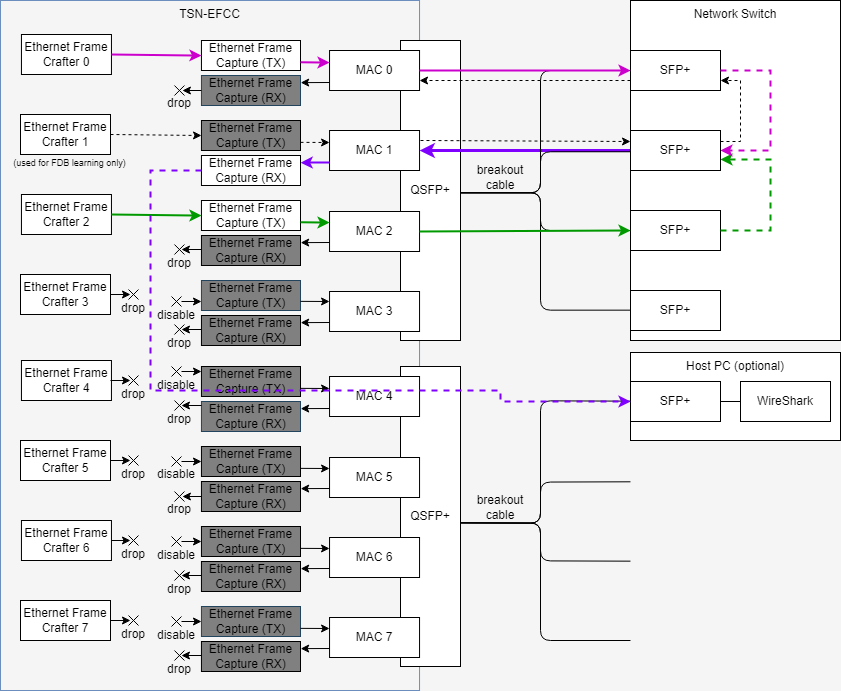

In [4]:
if configuration == 'with_switch':
  display(Markdown('Please connect Port0 (MAC0), Port1 (MAC1) and Port2 (MAC2) of the TSN-EFCC to network switch as shown below.'))
  display(Image(filename='img/overwiew_sample_design-10g_example_configuration3.drawio.png', embed=True))
else:
  display(Markdown('**If a network switch is not available, skip this example.**'))

### 1-A. Make initial settings

Set JTAG2AXI target. As default, this target is expected to be target 5.  
If you want to different target value, change the next value.

In [5]:
xsdb_target = 5

PORT_TX0=0
PORT_TX1=2
PORT_RX=1
# PORT_HOST=4   # optional

In [6]:
# Open xsdb device to access TSN-EFCC
xsdb = pyxsdb.PyXsdb()
xsdb.connect()
xsdb.target(xsdb_target)

# Get the default address table object
default_addr_table = tsn_efcc.default_tsn_efcc_address_table_10g()
# print(f'{default_addr_table}\n')

# Get the default config table object
default_config_table = tsn_efcc.default_axis_switch_config_table_10g()
# print(f'{default_config_table}\n')

# Initialize AxisNetSwitch object
switch = tsn_efcc.AxisNetSwitch(xsdb, xsdb_target, default_addr_table, default_config_table)

# Initialize the ef_crafter
ef_crafter = tsn_efcc.EFCrafter(xsdb, xsdb_target, default_addr_table)

# Just to be sure, stop ef_crafter
ef_crafter.reset(0xff)

xsdb server launched.


To be on the safe side, update the look-up table (LUT) so that the MAC address and IP address are different from those of the NIC.

In [7]:
macbase = 'aa:bb:cc:dd:ee:'
ipbase = '192.168.11.'
for i in range(8):
    for j in range(8):
        macstr = macbase + "{:02x}".format(j+1)
        ipstr = ipbase + str(j+1)
        ef_crafter.set_mac_address(port=i, index=j+1, val=macstr)
        ef_crafter.set_ip_address(port=i, index=j+1, val=ipstr)

In [8]:
if configuration == 'with_switch':
  display(Markdown('### 1-B. Set up the AXIS Switch'))

### 1-B. Set up the AXIS Switch

In [9]:
if configuration == 'with_switch':
    print(f'In this test, we connect ef_crafter0(port 8) to TX{PORT_TX0}(port {PORT_TX0}) and ef_crafter2(port 10) to TX{PORT_TX1}(port {PORT_TX1}).')
    print(f'In addition, as FDB updates require the sending of frames from the receive port to the network switch, connect Frame Generator1 (port 9) to TX{PORT_RX} (port {PORT_RX}).')
    
    print('Other input ports are disconnected from output port.')

In this test, we connect ef_crafter0(port 8) to TX0(port 0) and ef_crafter2(port 10) to TX2(port 2).
In addition, as FDB updates require the sending of frames from the receive port to the network switch, connect Frame Generator1 (port 9) to TX1 (port 1).
Other input ports are disconnected from output port.


In [10]:
if configuration == 'with_switch':
    switch.start_config()
    switch.connect(8, PORT_TX0)          # ef_crafter 0 -> MAC TX (PORT_TX0)
    switch.connect(10, PORT_TX1)         # ef_crafter 2 -> MAC TX (PORT_TX1)
    switch.connect(9, PORT_RX)           # ef_crafter 1 -> MAC TX (PORT_RX, for FDB learning)
    # switch.connect(PORT_RX, PORT_HOST)   # MAC RX (PORT_RX) -> MAC TX (PORT_HOST, optional for wireshark)
    switch.commit()
    
    # show current switch status
    switch.show_configuration()

input MAC0-RX -> Drop
input MAC1-RX -> Drop
input MAC2-RX -> Drop
input MAC3-RX -> Drop
input MAC4-RX -> Drop
input MAC5-RX -> Drop
input MAC6-RX -> Drop
input MAC7-RX -> Drop
input EFCrafter0 -> MAC0-TX
input EFCrafter1 -> MAC1-TX
input EFCrafter2 -> MAC2-TX
input EFCrafter3 -> Drop
input EFCrafter4 -> Drop
input EFCrafter5 -> Drop
input EFCrafter6 -> Drop
input EFCrafter7 -> Drop


In [11]:
if configuration == 'with_switch':
  display(Markdown('### 1-C. Update ef_capture setting'))
  display(Markdown('Configure capture (2 TX, 1 RX)'))

### 1-C. Update ef_capture setting

Configure capture (2 TX, 1 RX)

In [12]:
if configuration == 'with_switch':
    capture0 = tsn_efcc.EFCapture(xsdb, xsdb_target, default_addr_table, PORT_TX0, direction='tx')    # use capture of PORT_TX0 to record TX timestamp
    capture1 = tsn_efcc.EFCapture(xsdb, xsdb_target, default_addr_table, PORT_RX, direction='rx')     # use capture of PORT_RX to record RX timestamp
    capture2 = tsn_efcc.EFCapture(xsdb, xsdb_target, default_addr_table, PORT_TX1, direction='tx')    # use capture of PORT_TX1 to record TX timestamp
    
    # Just to be sure, let's reset the timestamp recording status
    capture0.reset()
    capture1.reset()
    capture2.reset()

In [13]:
if configuration == 'with_switch':
    display(Markdown('### 1-D. Prepare send frames'))
    print(f"To ensure that the total bandwidth is just over 10Gbps, let's generate frames to be transmitted at about 6666Mbps from port{PORT_TX0} and 7500Mbps from port{PORT_TX1}.")

### 1-D. Prepare send frames

To ensure that the total bandwidth is just over 10Gbps, let's generate frames to be transmitted at about 6666Mbps from port0 and 7500Mbps from port2.


In [14]:
if configuration == 'with_switch':
    print(f'Firstly, we create a frame information which flows Port{PORT_TX0} -> Port{PORT_RX}.')
    print('Transmitting one NOP frame for every two normal frames results in a 2/3 transfer rate.')

Firstly, we create a frame information which flows Port0 -> Port1.
Transmitting one NOP frame for every two normal frames results in a 2/3 transfer rate.


In [15]:
eol_frame = tsn_efcc.Frame.eol()

if configuration == 'with_switch':
    frame0 = tsn_efcc.Frame('Frame0').ether(dst=PORT_RX+1, src=PORT_TX0+1).ipv4(dst=PORT_RX+1, src=PORT_TX0+1).udp(dst=2000, src=1000).payload(length=1024)
    
    ef_crafter.set_frame(port=0, index=0, frame=frame0)
    ef_crafter.set_frame(port=0, index=1, frame=frame0)
    ef_crafter.set_frame(port=0, index=2, frame=frame0.clone().nop())
    ef_crafter.set_frame(port=0, index=3, frame=eol_frame)
    
    # Dump the frame information pushed to ef_crafter
    for frame in ef_crafter.get_frames(port=0):
        print(frame)

Frame0000.ETHER(dst=2, src=1).IPV4(dst=2, src=1).UDP(dst=2000, src=1000).Payload(length=1024)
Frame0001.ETHER(dst=2, src=1).IPV4(dst=2, src=1).UDP(dst=2000, src=1000).Payload(length=1024)
Frame0002.ETHER(dst=2, src=1).IPV4(dst=2, src=1).UDP(dst=2000, src=1000).Payload(length=1024).Nop()
EOL()


In [16]:
if configuration == 'with_switch':
    print(f'Next, we will create the frame information that will flow from Port{PORT_TX1} to Port{PORT_RX}.')
    print('Transmitting one NOP frame for every three normal frames results in a 3/4 transfer rate.')

Next, we will create the frame information that will flow from Port2 to Port1.
Transmitting one NOP frame for every three normal frames results in a 3/4 transfer rate.


In [17]:
if configuration == 'with_switch':
    frame2 = tsn_efcc.Frame('Frame2').ether(dst=PORT_RX+1, src=PORT_TX1+1).ipv4(dst=PORT_RX+1, src=PORT_TX1+1).udp(dst=2002, src=1002).payload(length=1024)
    
    ef_crafter.set_frame(port=2, index=0, frame=frame2)
    ef_crafter.set_frame(port=2, index=1, frame=frame2)
    ef_crafter.set_frame(port=2, index=2, frame=frame2)
    ef_crafter.set_frame(port=2, index=3, frame=frame2.clone().nop())
    ef_crafter.set_frame(port=2, index=4, frame=eol_frame)
    
    # Dump the frame information pushed to ef_crafter
    for frame in ef_crafter.get_frames(port=2):
        print(frame)

Frame0000.ETHER(dst=2, src=3).IPV4(dst=2, src=3).UDP(dst=2002, src=1002).Payload(length=1024)
Frame0001.ETHER(dst=2, src=3).IPV4(dst=2, src=3).UDP(dst=2002, src=1002).Payload(length=1024)
Frame0002.ETHER(dst=2, src=3).IPV4(dst=2, src=3).UDP(dst=2002, src=1002).Payload(length=1024)
Frame0003.ETHER(dst=2, src=3).IPV4(dst=2, src=3).UDP(dst=2002, src=1002).Payload(length=1024).Nop()
EOL()


In [18]:
if configuration == 'with_switch':
    print(f'In order for the FDB to learn port {PORT_RX}, a frame is also created to be output from port{PORT_RX}.')
    print(f'The destination can be port{PORT_TX0} or port{PORT_TX1}, but here port{PORT_TX0} is assumed.')

In order for the FDB to learn port 1, a frame is also created to be output from port1.
The destination can be port0 or port2, but here port0 is assumed.


In [19]:
if configuration == 'with_switch':
    frame1 = tsn_efcc.Frame('Frame1').ether(dst=PORT_TX0+1, src=PORT_RX+1).ipv4(dst=PORT_TX0+1, src=PORT_RX+1).udp(dst=2001, src=1001).payload(length=1024)
    
    ef_crafter.set_frame(port=1, index=0, frame=frame1)
    ef_crafter.set_frame(port=1, index=1, frame=eol_frame)
    
    # Dump the frame information pushed to ef_crafter
    for frame in ef_crafter.get_frames(port=1):
        print(frame)

Frame0000.ETHER(dst=1, src=2).IPV4(dst=1, src=2).UDP(dst=2001, src=1001).Payload(length=1024)
EOL()


In [20]:
if configuration == 'with_switch':
    print(f'To update the FDB for port{PORT_RX}, first send a frame from port{PORT_RX} to port{PORT_TX0}.')
    print(f'The FDB for port{PORT_TX0} and port{PORT_TX1} will be updated when the frame is sent in the next section.')

To update the FDB for port1, first send a frame from port1 to port0.
The FDB for port0 and port2 will be updated when the frame is sent in the next section.


In [21]:
if configuration == 'with_switch':
    # Send the frame from Port1 to Port0
    port1 = 1
    bit_mask = 1 << port1
    ef_crafter.reset(bit_mask)
    ef_crafter.start(bit_mask)
    
    # Wait for transmission to complete
    ef_crafter.wait(port1)

In [22]:
if configuration == 'with_switch':
  display(Markdown('### 1-E. Send frames from port0 and port2 simultaneously, in repeat mode'))
  display(Markdown('We use 1000 frames for evaluation.  '))
  display(Markdown('Firstly, use ef_crafter with repeat mode to send frames.'))

### 1-E. Send frames from port0 and port2 simultaneously, in repeat mode

We use 1000 frames for evaluation.  

Firstly, use ef_crafter with repeat mode to send frames.

In [23]:
if configuration == 'with_switch':
    num_frames = 1000
    
    port0 = 0
    port2 = 2
    bit_mask = (1 << port0) | (1 << port2)
    ef_crafter.reset(bit_mask)
    ef_crafter.set_repeat(bit_mask)
    ef_crafter.start(bit_mask)
    
    print(f'Wait until {num_frames} frames are sent')
    ef_crafter.wait_until(port0, num_frames)
    ef_crafter.wait_until(port2, num_frames)

Wait until 1000 frames are sent


In [24]:
if configuration == 'with_switch':
  display(Markdown('### 1-F. Transfer the recorded timestamps to the host computer'))

### 1-F. Transfer the recorded timestamps to the host computer

In [25]:
if configuration == 'with_switch':
    print('Wait for the timestamp for the sent frame to be saved.')
    print(f'Taking into account the difference between the transfer rates of port {PORT_TX0} and port {PORT_TX1}, port {PORT_RX} waits for more timestamps to be stored than the total number of transfer frames for both.')

Wait for the timestamp for the sent frame to be saved.
Taking into account the difference between the transfer rates of port 0 and port 2, port 1 waits for more timestamps to be stored than the total number of transfer frames for both.


In [26]:
if configuration == 'with_switch':
    capture0.wait(num_frames)
    capture2.wait(num_frames)
    capture1.wait(num_frames * 3)
    
    # Reset ef_crafter to stop repeating
    ef_crafter.reset(0xff)

Read timestamps from hardware.

In [27]:
if configuration == 'with_switch':
    send0_stat = capture0.read_timestamp(num_frames)
    send2_stat = capture2.read_timestamp(num_frames)
    recv_stat = capture1.read_timestamp(num_frames * 3)
    
    send0_stat.save_to_csv("3_send0.csv")
    send2_stat.save_to_csv("3_send2.csv")
    recv_stat.save_to_csv("3_recv.csv")
    
    capture0.reset()
    capture1.reset()
    capture2.reset()

read_timestamp: |██████████████████████████████| 1000 / 1000
read_timestamp: |██████████████████████████████| 1000 / 1000
read_timestamp: |██████████████████████████████| 3000 / 3000


In [28]:
if configuration == 'with_switch':
  display(Markdown('### 1-G. Check the recorded timestamps'))
  display(Markdown('The first five of the send timestamps and the first ten of the receive timestamps are'))

### 1-G. Check the recorded timestamps

The first five of the send timestamps and the first ten of the receive timestamps are

In [29]:
if configuration == 'with_switch':
    print(f'Timestamp(Port{PORT_TX0} TX):')
    for k, v in list(send0_stat.get_stats().items())[:5]:
        print(f'  id={k}, timestamp={v}')
    print(f'Timestamp(Port{PORT_TX1} TX):')
    for k, v in list(send2_stat.get_stats().items())[:5]:
        print(f'  id={k}, timestamp={v}')
    print(f'Timestamp(Port{PORT_RX} RX):')
    for k, v in list(recv_stat.get_stats().items())[:5]:
        print(f'  id={k}, timestamp={v}')

Timestamp(Port0 TX):
  id=0, timestamp=3104960559
  id=1, timestamp=3104960696
  id=3, timestamp=3104960970
  id=4, timestamp=3104961107
  id=6, timestamp=3104961381
Timestamp(Port2 TX):
  id=1073741824, timestamp=3104960559
  id=1073741825, timestamp=3104960696
  id=1073741826, timestamp=3104960833
  id=1073741828, timestamp=3104961107
  id=1073741829, timestamp=3104961244
Timestamp(Port1 RX):
  id=0, timestamp=3104960682
  id=1073741824, timestamp=3104960819
  id=1, timestamp=3104960956
  id=1073741825, timestamp=3104961093
  id=3, timestamp=3104961230


In [30]:
if configuration == 'with_switch':
    print(f'The upper three bits of the id are set to 0 for frames from port {PORT_TX0}, where ef_crafter0 was used, and the upper three bits of the id are set to 1 for frames from port {PORT_TX1}, where ef_crafter1 was used.')
    print(f'It is therefore possible to classify the timestamps received on port {PORT_RX} using the id.')

The upper three bits of the id are set to 0 for frames from port 0, where ef_crafter0 was used, and the upper three bits of the id are set to 1 for frames from port 2, where ef_crafter1 was used.
It is therefore possible to classify the timestamps received on port 1 using the id.


In [31]:
if configuration == 'with_switch':
    recv0_stat = recv_stat.get_intersection(send0_stat)
    recv2_stat = recv_stat.get_intersection(send2_stat)
    
    recv0_stat.save_to_csv("3_recv0.csv")
    recv2_stat.save_to_csv("3_recv2.csv")

In [32]:
if configuration == 'with_switch':
    print(f'Timestamp(Port{PORT_RX} RX all):')
    for k, v in list(recv_stat.get_stats().items())[:10]:
        print(f'  id={k}, timestamp={v}')
    print(f'Timestamp(Port{PORT_TX0} -> Port{PORT_RX} RX):')
    for k, v in list(recv0_stat.get_stats().items())[:5]:
        print(f'  id={k}, timestamp={v}')
    print(f'Timestamp(Port{PORT_TX1} -> Port{PORT_RX} RX):')
    for k, v in list(recv2_stat.get_stats().items())[:5]:
        # print(f'  id={k}, timestamp={v}') # original id
        print(f'  id={k - 2 * 2**29}, timestamp={v}') # id minus ef_crafter number

Timestamp(Port1 RX all):
  id=0, timestamp=3104960682
  id=1073741824, timestamp=3104960819
  id=1, timestamp=3104960956
  id=1073741825, timestamp=3104961093
  id=3, timestamp=3104961230
  id=1073741826, timestamp=3104961367
  id=4, timestamp=3104961504
  id=1073741828, timestamp=3104961641
  id=6, timestamp=3104961778
  id=1073741829, timestamp=3104961915
Timestamp(Port0 -> Port1 RX):
  id=0, timestamp=3104960682
  id=1, timestamp=3104960956
  id=3, timestamp=3104961230
  id=4, timestamp=3104961504
  id=6, timestamp=3104961778
Timestamp(Port2 -> Port1 RX):
  id=0, timestamp=3104960819
  id=1, timestamp=3104961093
  id=2, timestamp=3104961367
  id=4, timestamp=3104961641
  id=5, timestamp=3104961915


In [33]:
if configuration == 'with_switch':
  display(Markdown('### 1-H. Evaluate latency and throughput for each input port'))
  display(Markdown('Calculates throughput and latency using the transmit and receive timestamps of frames sent from port 0.'))

### 1-H. Evaluate latency and throughput for each input port

Calculates throughput and latency using the transmit and receive timestamps of frames sent from port 0.

In [34]:
if configuration == 'with_switch':
    # Show statistics information of the timestamp difference
    recv0_stat.subtract(send0_stat).summary(freq_mhz=FREQ_MHZ, name=f'Latency: port{PORT_TX0}', f=sys.stdout)
    
    start_timestamp = min(send0_stat.get_timestamps())
    end_timestamp = max(send0_stat.get_timestamps())
    duration_sec = (end_timestamp - start_timestamp) / (FREQ_MHZ * 1000 * 1000)
    
    l2_size, l7_size = frame0.get_length()
    print(f'l2 size of Frame0: {l2_size}, l7 size of Frame0: {l7_size}')
    def timestamp_to_size(tid: int) -> int:
        return l2_size
    
    tsn_efcc.TimestampStatistic.summary_bandwidth(send0_stat, recv0_stat, FREQ_MHZ, timestamp_to_size, duration_sec=duration_sec, name=f'Throughput: port{PORT_TX0}', f=sys.stdout)

--------------------------------
TimestampStat(Latency: port0): id range = [0x00000000:0x000005da]
Minimum Timestamp: 787.20 ns
Maximum Timestamp: 25331.20 ns
Average Timestamp: 21638.36 ns
Stddev Timestamp: 4919.59 ns
l2 size of Frame0: 1070, l7 size of Frame0: 1024
--------------------------------
TimestampStat(Throughput: port0): id range = [0x00000000:0x000005da]
# of sent frames: 1000
send rate: 6517.205 Mbps
# of recvd frames: 764
recv rate: 4979.145 Mbps
# of dropped frames: 236
drop rate: 23.600 %


In [35]:
if configuration == 'with_switch':
  display(Markdown('Calculates throughput and latency using the transmit and receive timestamps of frames sent from port 2.'))

Calculates throughput and latency using the transmit and receive timestamps of frames sent from port 2.

In [36]:
if configuration == 'with_switch':
    # Show statistics information of the timestamp difference
    recv2_stat.subtract(send2_stat).summary(freq_mhz=FREQ_MHZ, name=f'Latency: port{PORT_TX1}', f=sys.stdout)
    
    start_timestamp = min(send2_stat.get_timestamps())
    end_timestamp = max(send2_stat.get_timestamps())
    duration_sec = (end_timestamp - start_timestamp) / (FREQ_MHZ * 1000 * 1000)
    
    l2_size, l7_size = frame2.get_length()
    print(f'l2 size of Frame2: {l2_size}, l7 size of Frame0: {l7_size}')
    def timestamp_to_size(tid: int) -> int:
        return l2_size
    
    tsn_efcc.TimestampStatistic.summary_bandwidth(send2_stat, recv2_stat, FREQ_MHZ, timestamp_to_size, name=f'Throughput: port{PORT_TX1}', f=sys.stdout)

--------------------------------
TimestampStat(Latency: port2): id range = [0x40000000:0x40000534]
Minimum Timestamp: 1664.00 ns
Maximum Timestamp: 25331.20 ns
Average Timestamp: 21275.03 ns
Stddev Timestamp: 4772.52 ns
l2 size of Frame2: 1070, l7 size of Frame0: 1024
--------------------------------
TimestampStat(Throughput: port2): id range = [0x40000000:0x40000534]
# of sent frames: 1000
send rate: 7179.088 Mbps
# of recvd frames: 680
recv rate: 4881.780 Mbps
# of dropped frames: 320
drop rate: 32.000 %


## 2. Send frames by adjusting the frame interval to match the target transfer rate

Connect TSN-EFCC ports 0 (MAC0) and 4 (MAC4) with an Ethernet cable.

Alternatively, connect ports 0 (MAC0) and 4 (MAC4) to a network switch.

(This example uses the same structure as the first example for ef_capture_hello)

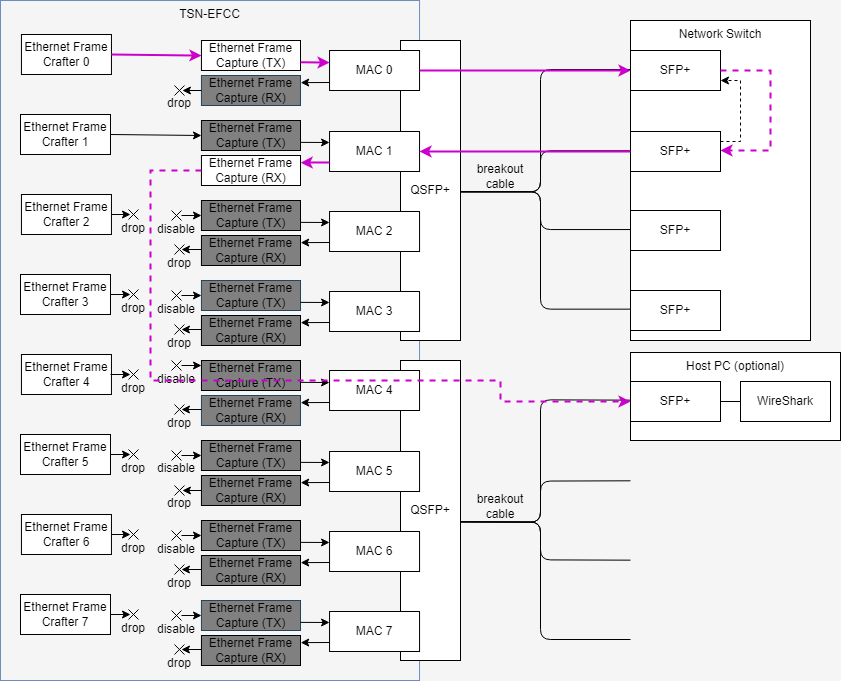

In [37]:
if configuration == 'with_switch':
  display(Markdown('Connect TSN-EFCC ports 0 (MAC0) and 4 (MAC4) with an Ethernet cable.'))
  display(Markdown('Alternatively, connect ports 0 (MAC0) and 4 (MAC4) to a network switch.'))
  display(Markdown('(This example uses the same structure as the first example for ef_capture_hello)'))
  display(Image(filename='img/overwiew_sample_design-10g_example_configuration2.drawio.png', embed=True))
else:
  display(Markdown('**If a network switch is not available, use a QSFP+ cable to create a loopback. However, the output to the Host PC cannot be used.**  '))
  display(Markdown('**In this case, set PORT_RX to `PORT_TX + 4`.**  '))
  display(Image(filename='img/overwiew_sample_design-10g_example_configuration2_cableloopback.drawio.png', embed=True))

In [38]:
if configuration == 'with_switch':
    PORT_TX=0
    PORT_RX=1
    # PORT_HOST=4   # optional
else:
    # Settings for cable loopback configuration
    PORT_TX=0
    PORT_RX=(PORT_TX+4) % 8

### 2-A. Update internal switch configuration

In [39]:
print(f'In this test, we connect ef_crafter0(port 8) to TX{PORT_TX}(port {PORT_TX}).')
print(f'In addition, ef_crafter1 (port 9) is connected to TX{PORT_RX} (port {PORT_RX}) for FDB learning when using a switch.')
print('Other input ports are disconnected from output port.')

In this test, we connect ef_crafter0(port 8) to TX0(port 0).
In addition, ef_crafter1 (port 9) is connected to TX1 (port 1) for FDB learning when using a switch.
Other input ports are disconnected from output port.


In [40]:
switch.start_config()
switch.connect(8, PORT_TX)           # ef_crafter0 -> MAC TX (PORT_TX)
                                     # loopback by ethernet cable: MAC TX (PORT_TX) -> MAC RX (PORT_RX), MAC TX (PORT_RX) -> MAC RX (PORT_TX)
switch.connect(9, PORT_RX)           # ef_crafter1 -> MAC TX (PORT_RX)
# switch.connect(PORT_RX, PORT_HOST)   # MAC RX (PORT_RX) -> MAC TX (PORT_HOST, optional for wireshark)
switch.commit()

# show current switch status
switch.show_configuration()

input MAC0-RX -> Drop
input MAC1-RX -> Drop
input MAC2-RX -> Drop
input MAC3-RX -> Drop
input MAC4-RX -> Drop
input MAC5-RX -> Drop
input MAC6-RX -> Drop
input MAC7-RX -> Drop
input EFCrafter0 -> MAC0-TX
input EFCrafter1 -> MAC1-TX
input EFCrafter2 -> Drop
input EFCrafter3 -> Drop
input EFCrafter4 -> Drop
input EFCrafter5 -> Drop
input EFCrafter6 -> Drop
input EFCrafter7 -> Drop


### 2-B. Update ef_capture setting

Configure capture (1 TX, 1 RX)

In [41]:
capture0 = tsn_efcc.EFCapture(xsdb, xsdb_target, default_addr_table, PORT_TX, direction='tx')    # use capture of PORT_TX to record TX timestamp
capture1 = tsn_efcc.EFCapture(xsdb, xsdb_target, default_addr_table, PORT_RX, direction='rx')    # use capture of PORT_RX to record RX timestamp

# Just to be sure, let's reset the timestamp recording status
capture0.reset()
capture1.reset()

### 2-C. Prepare send frames (Constant rate)
First decide on the frame size and average transfer rate.  
This time we will generate a frame without a VLAN TAG for UDP, so please specify the UDP payload size.

In [42]:
average_rate_mbps = 5000
payload_size = 1024

First create a normal frame.

In [43]:
valid_frame = tsn_efcc.Frame('valid_frame').ether(dst=PORT_RX+1, src=PORT_TX+1).ipv4(dst=PORT_RX+1, src=PORT_TX+1).udp(dst=2000, src=1000).payload(payload_size)

Next, calculate the frame transmission cycle and the target rate frame transmission cycle if there is no NOP frame or await.

In [44]:
ETHERHEADER = 14
IPHEADER = 20
UDPHEADER = 8
FCS = 4
PREAMBLE = 8
IFG = 12

BITS_PER_BYTE = 8
BITS_PER_CYCLE = 64
BYTES_PER_CYCLE = BITS_PER_CYCLE / BITS_PER_BYTE
NS_PER_CYCLE = 1000 / FREQ_MHZ

framesize = ETHERHEADER + IPHEADER + UDPHEADER + payload_size + FCS
minperiod = framesize + PREAMBLE + IFG
min_cycle = minperiod / BYTES_PER_CYCLE

target_cycle = framesize * BITS_PER_BYTE / NS_PER_CYCLE / average_rate_mbps * 1000

The target transfer rate can be achieved by increasing the frame interval by `extra_cycle` = `target_cycle - min_cycle` using NOP frame and await.

The following conditions are used to register frames.
1. if `extra_cycle` is less than 127, use await only.
2. if `extra_cycle` is less than or equal to the maximum size of NOP, use an NOP frame only.
3. If `extra_cycle` is less than or equal to the maximum size of NOP + the maximum size of await, use a NOP frame and await.
4. If `extra_cycle` is greater than the maximum size of NOP + the maximum size of await, use multiple NOP frames and await.

Note that cases where `extra_cycle` is negative will result in an error because a transfer rate has been specified that exceeds the maximum that can be achieved with the payload size.

In the actual implementation, to simplify the description, conditional processing is done using `nop_length`, which is the payload size of the NOP frame, rather than the size of the NOP frame.
```python
nop_length = int(extra_cycle * BYTES_PER_CYCLE) - (ETHERHEADER + IPHEADER + UDPHEADER + FCS + PREAMBLE + IFG)
await_length = int(extra_cycle * BYTES_PER_CYCLE)
```

The next `prepare_frames()` function registers the NOP frames and await required to reach `target_cycle`, along with the send frame.

In [45]:
# Depends on the BRAM size of the design used
MAX_NUM_FRAMES = 32768 - 1

def prepare_frames(target_cycles):
    max_nop_length = 0xffff + 0x7F
    idx = 0
    for targetcycle in target_cycles:
        # Calculates the additional frame interval required
        extra_cycle = int(targetcycle - min_cycle)

        # Calculates the size of the NOP frame and the size of the await required to reach extra_cycle.
        nop_length = int(extra_cycle * BYTES_PER_CYCLE) - (ETHERHEADER + IPHEADER + UDPHEADER + FCS + PREAMBLE + IFG)
        await_length = int(extra_cycle * BYTES_PER_CYCLE)

        if extra_cycle < 0:
            # The value of average_rate_mbps is invalid
            raise ValueError('Error: target rate({average_rate_mbps}) exceed line rate of the payload size({payload_size}). Please reduce average_rate_mbps')
        elif nop_length >= max_nop_length:
            # Multiple NOP frames and await are required
            await_length = 0x7F
            ef_crafter.set_frame(0, idx, valid_frame.clone().payload(payload_size).additional_wait(await_length))
            idx += 1
            remain = nop_length - await_length
            cnt = 0
            # Add several NOP frames until the required frame interval is achieved
            while (remain > 0):
                nop_length = min(0xffff, remain)
                remain -= nop_length
                await_length = min(0x7F, remain)
                remain -= await_length
                ef_crafter.set_frame(0, idx, valid_frame.clone().payload(nop_length).nop().additional_wait(await_length))
                idx += 1
                cnt += 1
                # print(f'    #{cnt} NOP frame, nop_length = {nop_length}, await_length = {await_length}')
        elif await_length <= 127:
            # Use await only
            ef_crafter.set_frame(0, idx, valid_frame.clone().payload(payload_size).additional_wait(await_length))
            idx += 1
        elif nop_length > 0xffff:
            # Use a NOP frame and await
            await_length = nop_length - 0xffff
            ef_crafter.set_frame(0, idx, valid_frame)
            idx += 1
            ef_crafter.set_frame(0, idx, valid_frame.clone().payload(0xffff).nop().additional_wait(nop_length))
            idx += 1
        else:
            # Use a NOP frame only
            ef_crafter.set_frame(0, idx, valid_frame)
            idx += 1
            ef_crafter.set_frame(0, idx, valid_frame.clone().payload(nop_length).nop())
            idx += 1
            await_length = 0

    # add eol frame
    ef_crafter.set_frame(0, idx, eol_frame)
    idx += 1

    if idx >= MAX_NUM_FRAMES:
        raise ValueError(f'The number of frames exceeds the buffer size of ef_crafter. Please consider to reduce num frames. current_index={idx}, buffer_size={MAX_NUM_FRAMES}')

In [46]:
prepare_frames([target_cycle])

Dump the frame information pushed to ef_crafter.

In [47]:
for frame in ef_crafter.get_frames(port=0):
    print(frame)

Frame0000.ETHER(dst=2, src=1).IPV4(dst=2, src=1).UDP(dst=2000, src=1000).Payload(length=1024)
Frame0001.ETHER(dst=2, src=1).IPV4(dst=2, src=1).UDP(dst=2000, src=1000).Payload(length=982).Nop()
EOL()


In [48]:
print(f'In order for the FDB to learn port {PORT_RX}, a frame is also created to be output from port{PORT_RX}.')

In order for the FDB to learn port 1, a frame is also created to be output from port1.


In [49]:
frame1 = tsn_efcc.Frame('Frame1').ether(dst=PORT_TX+1, src=PORT_RX+1).ipv4(dst=PORT_TX+1, src=PORT_RX+1).udp(dst=2001, src=1001).payload(length=1024)

ef_crafter.set_frame(port=1, index=0, frame=frame1)
ef_crafter.set_frame(port=1, index=1, frame=eol_frame)

# Dump the frame information pushed to ef_crafter
for frame in ef_crafter.get_frames(port=1):
    print(frame)

Frame0000.ETHER(dst=1, src=2).IPV4(dst=1, src=2).UDP(dst=2001, src=1001).Payload(length=1024)
EOL()


In [50]:
print(f'To update the FDB for port{PORT_RX}, first send a frame from port{PORT_RX} to port{PORT_TX}.')
print(f'The FDB for port{PORT_TX} will be updated when the frame is sent in the next section.')

To update the FDB for port1, first send a frame from port1 to port0.
The FDB for port0 will be updated when the frame is sent in the next section.


In [51]:
# Send the frame from PORT_RX to PORT_TX
port1 = 1
bit_mask = 1 << port1
ef_crafter.reset(bit_mask)
ef_crafter.start(bit_mask)

# Wait for transmission to complete
ef_crafter.wait(port1)

### 2-D. Send frames from port0 to port1, in repeat mode

As the registration is for a normal frame, enable repeat and send the required number of frames.

In [52]:
num_frames = 1000

In [53]:
port = 0
bit_mask = 1 << port
ef_crafter.reset(bit_mask)
ef_crafter.set_repeat(bit_mask)
ef_crafter.start(bit_mask)
ef_crafter.wait_until(port, num_frames)

### 2-E. Transfer the recorded timestamps to the host computer

In [54]:
capture0.wait(num_frames)
capture1.wait(num_frames)

# Reset ef_crafter to stop repeating
ef_crafter.reset(0xff)

Read timestamps from hardware.

In [55]:
send_stat = capture0.read_timestamp(num_frames)
recv_stat = capture1.read_timestamp(num_frames)

send_stat.save_to_csv("3_2_send.csv")
recv_stat.save_to_csv("3_2_recv.csv")

capture0.reset()
capture1.reset()

read_timestamp: |██████████████████████████████| 1000 / 1000
read_timestamp: |██████████████████████████████| 1000 / 1000


### 2-F. Evaluate latency and throughput for each input port

Calculates throughput and latency using the transmit and receive timestamps of frames sent from port 0.

In [56]:
# Show statistics information of the timestamp difference
recv_stat.subtract(send_stat).summary(freq_mhz=FREQ_MHZ, name='Latency: Constant rate', f=sys.stdout)

start_timestamp = min(send_stat.get_timestamps())
end_timestamp = max(send_stat.get_timestamps())
duration_sec = (end_timestamp - start_timestamp) / (FREQ_MHZ * 1000 * 1000)

l2_size, l7_size = valid_frame.get_length()
print(f'l2 size of Frame2: {l2_size}, l7 size of Frame0: {l7_size}')
def timestamp_to_size(tid: int) -> int:
    return l2_size

tsn_efcc.TimestampStatistic.summary_bandwidth(send_stat, recv_stat, FREQ_MHZ, timestamp_to_size, duration_sec=duration_sec, name='Throughput: Constant rate', f=sys.stdout)

--------------------------------
TimestampStat(Latency: Constant rate): id range = [0x00000000:0x000007ce]
Minimum Timestamp: 787.20 ns
Maximum Timestamp: 793.60 ns
Average Timestamp: 788.07 ns
Stddev Timestamp: 2.19 ns
l2 size of Frame2: 1070, l7 size of Frame0: 1024
--------------------------------
TimestampStat(Throughput: Constant rate): id range = [0x00000000:0x000007ce]
# of sent frames: 1000
send rate: 4995.667 Mbps
# of recvd frames: 1000
recv rate: 4995.667 Mbps
# of dropped frames: 0
drop rate: 0.000 %


Check the histogram to see if the transmission interval is constant.

In [57]:
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

def plothist_rate(stat, freq_mhz, frame_size, label):
    ts = list(stat.get_timestamps())
    interval = np.array(ts[1:]) - np.array(ts[0:-1])

    rate = []
    for val in interval:
        rate.append(int((freq_mhz * BITS_PER_CYCLE) * (frame_size / BYTES_PER_CYCLE) / np.asarray(val)))
    plt.hist(rate, rwidth=0.8, bins=50, range=(0, 10000))

    plt.title(f'frame rate histogram ({label})')
    plt.ylabel('the number of frames')
    plt.xlabel('frame rate [Mbps]')
    # plt.savefig(filename, bbox_inches='tight', pad_inches=0.1)
    plt.show()
    plt.cla()
    plt.clf()

def plothist_interval(stat, label):
    ts = list(stat.get_timestamps())
    interval = np.array(ts[1:]) - np.array(ts[0:-1])

    i_min = min(interval)
    i_max = max(interval)
    if i_max < i_min + 1000:
        i_min = i_min - 500
        i_max = i_max + 500    
    plt.hist(interval, rwidth=0.8, bins=50, range=(i_min, i_max))

    plt.title(f'frame interval histogram ({label})')
    plt.ylabel('the number of frames')
    plt.xlabel('frame interval [Cycles]')
    # plt.savefig(filename, bbox_inches='tight', pad_inches=0.1)
    plt.show()
    plt.cla()
    plt.clf()

def draw_graph(send_stat, recv_stat, freq_mhz, frame_size):
    plothist_interval(send_stat, 'Send interval')
    plothist_interval(recv_stat, 'Receive interval')
    plothist_rate(send_stat, freq_mhz, frame_size, 'Send rate')
    plothist_rate(recv_stat, freq_mhz, frame_size, 'Receive rate')

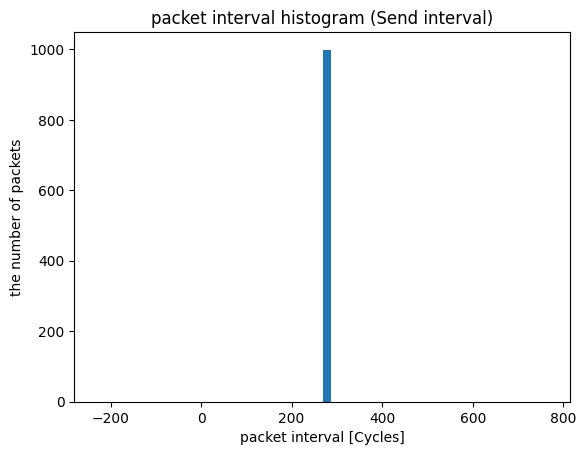

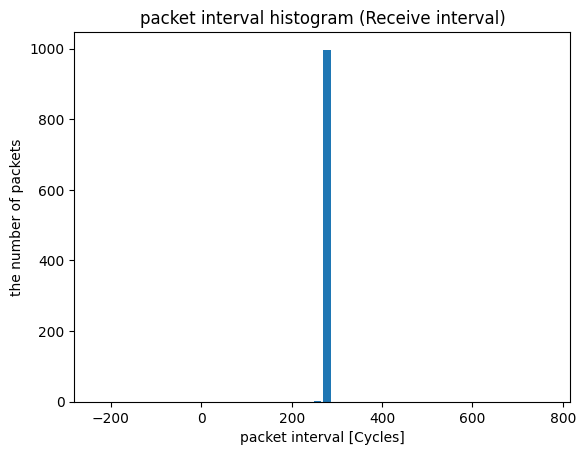

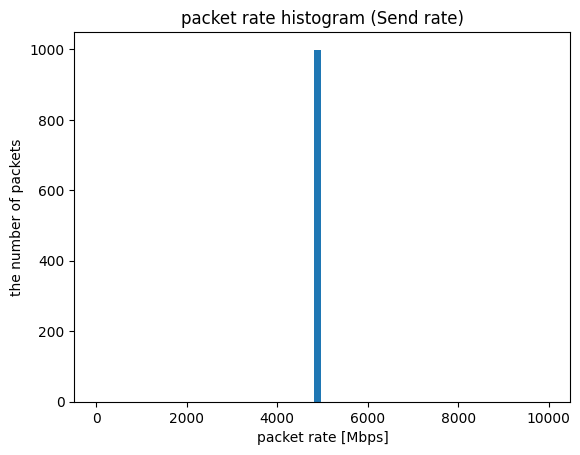

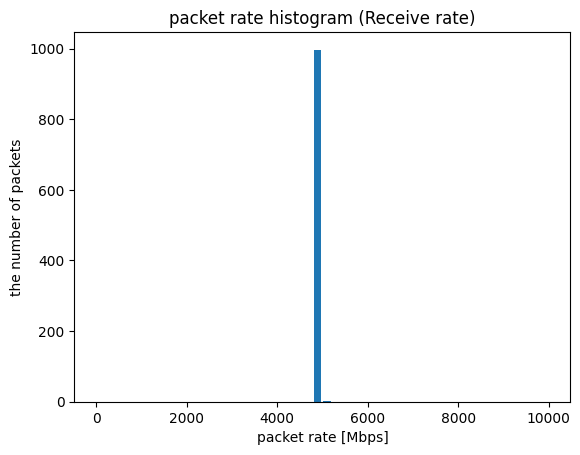

<Figure size 640x480 with 0 Axes>

In [58]:
draw_graph(send_stat, recv_stat, FREQ_MHZ, framesize)

## 3. Sends frames at a random transmission rate that follows an exponential distribution
Next, we calculate `target_cycle` using the exponential distribution with the specified average rate.

### 3-A. Generate random numbers that follow an exponential distribution

We use the scipy function expon.rvs() to generate the array of exponential distributions.  
The $ \lambda $ is the number of frames sent per second, and we set the $ \frac{1}{\lambda} $ to the `scale` parameter of expon.rvs().  
The random number generated is the time from the beginning of the frame to the beginning of the next frame, expressed in seconds, so you can convert it to cycles by dividing it by the time in a cycle.

In [59]:
from scipy.stats import expon
import math
size_bits = framesize * BITS_PER_BYTE
exp_rate = average_rate_mbps * 1000 * 1000
num_frames_per_seconds = exp_rate / size_bits

p = expon.rvs(scale=1/num_frames_per_seconds, size=num_frames, random_state=0)
target_cycles = p / NS_PER_CYCLE * 1000 * 1000 * 1000

However, the minimum value of the random number generated is zero, so the transfer rate becomes infinite at this point.

In [60]:
exp_rate = average_rate_mbps * 1000 * 1000
num_frames_per_seconds = exp_rate / size_bits

p = expon.rvs(scale=1/num_frames_per_seconds, size=1000, random_state=0)
target_cycles = p / NS_PER_CYCLE * 1000 * 1000 * 1000

tx_rates_mbps = 1000 / target_cycles * framesize
print(max(tx_rates_mbps))

7324478.172177218


Therefore, by specifying the minimum number of seconds between the start of one frame and the start of the next, `min_period_sec`, in the `loc` parameter of exponent.rvs(), you can limit the maximum transfer speed.

In [61]:
# Calculate the offset value for an exponential distribution
min_period_sec = min_cycle * NS_PER_CYCLE / 1000.0 / 1000.0 / 1000.0

p = expon.rvs(loc = min_period_sec, scale=1/num_frames_per_seconds - min_period_sec, size=num_frames, random_state=0)
target_cycles = (p / NS_PER_CYCLE * 1000 * 1000 * 1000 + 0.5).astype(np.uint32)

tx_rates_mbps = 1000 / target_cycles * framesize
print(max(tx_rates_mbps))

7867.647058823529


### 3-B. Prepare send frames (Exponential distribution)

The processing after calculating `target_cycles` is the same as for the constant rate.

In [62]:
prepare_frames(target_cycles)

Dump the first 10 frames of the frame information pushed to ef_crafter.

In [63]:
for frame in ef_crafter.get_frames(port=0, max_num=10):
    print(frame)

Frame0000.ETHER(dst=2, src=1).IPV4(dst=2, src=1).UDP(dst=2000, src=1000).Payload(length=1024)
Frame0001.ETHER(dst=2, src=1).IPV4(dst=2, src=1).UDP(dst=2000, src=1000).Payload(length=766).Nop()
Frame0002.ETHER(dst=2, src=1).IPV4(dst=2, src=1).UDP(dst=2000, src=1000).Payload(length=1024)
Frame0003.ETHER(dst=2, src=1).IPV4(dst=2, src=1).UDP(dst=2000, src=1000).Payload(length=1246).Nop()
Frame0004.ETHER(dst=2, src=1).IPV4(dst=2, src=1).UDP(dst=2000, src=1000).Payload(length=1024)
Frame0005.ETHER(dst=2, src=1).IPV4(dst=2, src=1).UDP(dst=2000, src=1000).Payload(length=894).Nop()
Frame0006.ETHER(dst=2, src=1).IPV4(dst=2, src=1).UDP(dst=2000, src=1000).Payload(length=1024)
Frame0007.ETHER(dst=2, src=1).IPV4(dst=2, src=1).UDP(dst=2000, src=1000).Payload(length=758).Nop()
Frame0008.ETHER(dst=2, src=1).IPV4(dst=2, src=1).UDP(dst=2000, src=1000).Payload(length=1024)
Frame0009.ETHER(dst=2, src=1).IPV4(dst=2, src=1).UDP(dst=2000, src=1000).Payload(length=510).Nop()


### 3-C. Send frames from port0 to port1, in repeat mode

In [64]:
port = 0
bit_mask = 1 << port
ef_crafter.reset(bit_mask)
ef_crafter.set_repeat(bit_mask)
ef_crafter.start(bit_mask)
ef_crafter.wait_until(port, num_frames)

### 3-D. Transfer the recorded timestamps to the host computer

In [65]:
capture0.wait(num_frames)
capture1.wait(num_frames)

# Reset ef_crafter to stop repeating
ef_crafter.reset(0xff)

Read timestamps from hardware.

In [66]:
send_stat = capture0.read_timestamp(num_frames)
recv_stat = capture1.read_timestamp(num_frames)

send_stat.save_to_csv("3_3_send.csv")
recv_stat.save_to_csv("3_3_recv.csv")

capture0.reset()
capture1.reset()

read_timestamp: |██████████████████████████████| 1000 / 1000
read_timestamp: |██████████████████████████████| 1000 / 1000


### 3-E. Evaluate latency and throughput

Calculates throughput and latency using the transmit and receive timestamps of frames sent from port 0.

In [67]:
# Show statistics information of the timestamp difference
recv_stat.subtract(send_stat).summary(freq_mhz=FREQ_MHZ, name='Latency: Exponential distribution', f=sys.stdout)

start_timestamp = min(send_stat.get_timestamps())
end_timestamp = max(send_stat.get_timestamps())
duration_sec = (end_timestamp - start_timestamp) / (FREQ_MHZ * 1000 * 1000)

l2_size, l7_size = valid_frame.get_length()
print(f'l2 size of Frame0: {l2_size}, l7 size of Frame0: {l7_size}')
def timestamp_to_size(tid: int) -> int:
    return l2_size

tsn_efcc.TimestampStatistic.summary_bandwidth(send_stat, recv_stat, FREQ_MHZ, timestamp_to_size, duration_sec=duration_sec, name='Throughput: Exponential distribution', f=sys.stdout)

--------------------------------
TimestampStat(Latency: Exponential distribution): id range = [0x00000000:0x00000757]
Minimum Timestamp: 787.20 ns
Maximum Timestamp: 793.60 ns
Average Timestamp: 788.06 ns
Stddev Timestamp: 2.18 ns
l2 size of Frame0: 1070, l7 size of Frame0: 1024
--------------------------------
TimestampStat(Throughput: Exponential distribution): id range = [0x00000000:0x00000757]
# of sent frames: 1000
send rate: 4996.395 Mbps
# of recvd frames: 1000
recv rate: 4996.395 Mbps
# of dropped frames: 0
drop rate: 0.000 %


Check the histogram to see if the transmission interval is constant.

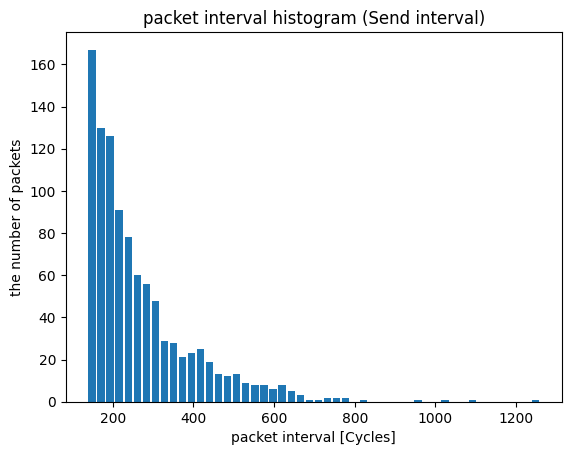

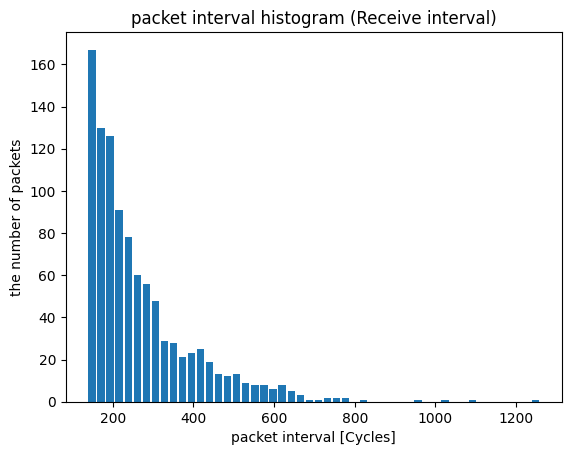

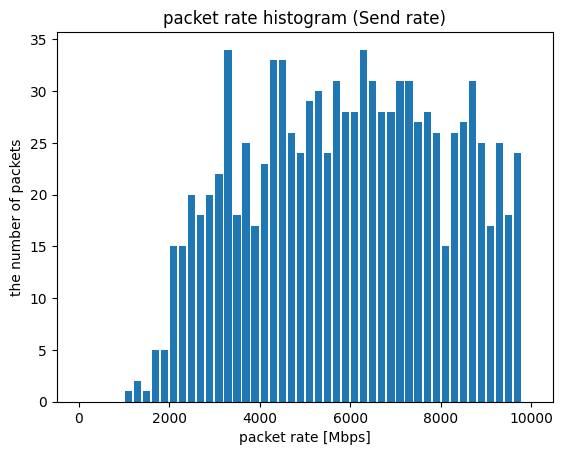

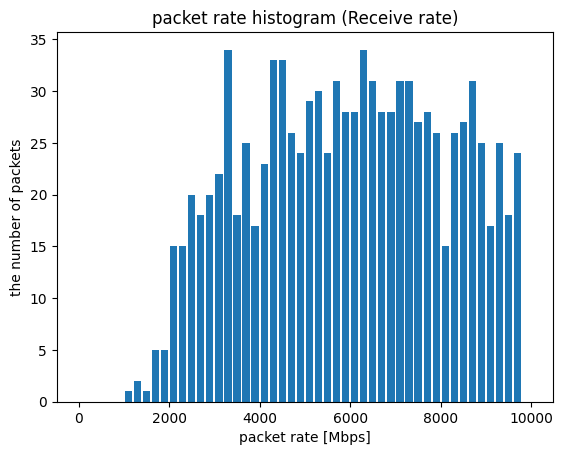

<Figure size 640x480 with 0 Axes>

In [68]:
draw_graph(send_stat, recv_stat, FREQ_MHZ, framesize)